In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib_venn import venn2, venn3
import seaborn as sns
from ALLCools.mcds import MCDS 

In [2]:
# mcds_path = '/ceph/MethDev/pbio/kay/data/Arab10_All_mcds.mcds'
mcds_path = '/ceph/MethDev/pbio/All_mcds.mcds'
rna_path = '/ceph/MethDev/pbio/novaseq_demux/count.csv'
meta_path ='/ceph/MethDev/pbio/data/Arab6_cells_and_clusters.csv'
seurat_path = '/ceph/MethDev/pbio/0523_seurat_metadata.csv'
rna_path = '/ceph/MethDev/pbio/Arab6_RNA_normalized_data.csv'

In [16]:
mcds = MCDS.open(mcds_paths = mcds_path, var_dim = 'gene')
rna_matrix = pd.read_csv(rna_path,index_col = 0).T
meta = pd.read_csv(meta_path)
seurat = pd.read_csv(seurat_path).set_index('Unnamed: 0')

In [10]:
#re-format and combine clusters
meta['Cell'] = meta['Cell'].str.replace('.','-')
meta = meta.set_index('Cell')

In [11]:
rna_matrix['cluster'] = meta['Cluster']
# rna_matrix = rna_matrix.groupby('cluster').mean()
rna_matrix

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980,cluster
NJ_221007_P1-2-K15-J3,0,0,0,44,0,69,0,0,0,0,...,20,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-E16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12
NJ_221007_P1-2-K15-C15,0,0,0,3,0,110,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P1-2-K15-J4,0,78,0,623,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
NJ_221007_P1-2-K15-M16,0,3,0,36,0,28,0,0,0,1,...,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,4
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
NJ_221007_P8-5-G10-N21,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2


In [12]:
sd = seurat[seurat['condition']=='Acute Stress']
ww = seurat[seurat['condition']=='Normal']

In [13]:
sd

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.5,seurat_clusters,cell_id,condition
Unnamed: 0,,,,,,,,
NJ_221007_P1-2-K15-J3,NJ,704365,4028,0,0,0,NJ_221007_P1-2-K15-J3,Acute Stress
NJ_221007_P1-2-K15-E16,NJ,169386,1628,0,9,9,NJ_221007_P1-2-K15-E16,Acute Stress
NJ_221007_P1-2-K15-C15,NJ,331484,2471,0,0,0,NJ_221007_P1-2-K15-C15,Acute Stress
NJ_221007_P1-2-K15-J4,NJ,705364,4407,0,6,6,NJ_221007_P1-2-K15-J4,Acute Stress
NJ_221007_P1-2-K15-M16,NJ,653935,3356,0,0,0,NJ_221007_P1-2-K15-M16,Acute Stress
...,...,...,...,...,...,...,...,...
NJ_221007_P3-1-C21-J1,NJ,357492,2291,0,5,5,NJ_221007_P3-1-C21-J1,Acute Stress
NJ_221007_P3-1-C21-A13,NJ,128540,1931,0,0,0,NJ_221007_P3-1-C21-A13,Acute Stress
NJ_221007_P3-1-C21-K14,NJ,289656,2028,0,4,4,NJ_221007_P3-1-C21-K14,Acute Stress


In [14]:
ww

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,RNA_snn_res.0.5,seurat_clusters,cell_id,condition
Unnamed: 0,,,,,,,,
NJ_221007_P6-5-I2-P10,NJ,180891,2057,0,3,3,NJ_221007_P6-5-I2-P10,Normal
NJ_221007_P6-5-I2-F22,NJ,160035,1700,0,1,1,NJ_221007_P6-5-I2-F22,Normal
NJ_221007_P6-5-I2-B9,NJ,140260,1253,0,2,2,NJ_221007_P6-5-I2-B9,Normal
NJ_221007_P6-5-I2-F9,NJ,205952,1807,0,2,2,NJ_221007_P6-5-I2-F9,Normal
NJ_221007_P6-5-I2-K22,NJ,365536,2566,0,1,1,NJ_221007_P6-5-I2-K22,Normal
...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,NJ,4853,688,0,2,2,NJ_221007_P8-5-G10-N10,Normal
NJ_221007_P8-5-G10-F22,NJ,10311,1438,0,1,1,NJ_221007_P8-5-G10-F22,Normal
NJ_221007_P8-5-G10-O10,NJ,4059,694,0,3,3,NJ_221007_P8-5-G10-O10,Normal


In [17]:
#get methylation fraction 
mCGN_mc = mcds.sel(
    mc_type = 'CGN',
    count_type = 'mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(
    mc_type = 'CGN',
    count_type = 'cov').gene_da.to_pandas()

# remove chromosomes with certain characteristics
mCGN_mc = mCGN_mc.loc[:,~mCGN_mc.columns.str.startswith(('ATM', 'ATC'))]
mCGN_cov = mCGN_cov.loc[:,~mCGN_cov.columns.str.startswith(('ATM', 'ATC'))]
# filter RNAs not ending in 0 or 5
mCGN_mc = mCGN_mc.loc[:, mCGN_mc.columns.str.endswith(('0', '5'))]
mCGN_cov = mCGN_cov.loc[:, mCGN_cov.columns.str.endswith(('0', '5'))]
mCGN_frac = mCGN_mc.div(mCGN_cov).fillna(0)

In [18]:
mCGN_frac

gene,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cell,,,,,,,,,,,,,,,,,,,,,
NJ_221007_P1-2-K15-I15,0.081633,0.000000,0.0,0.641618,0.192308,0.157303,0.019608,0.000000,0.000000,0.000000,...,0.090909,0.0,0.0,0.225352,0.000000,0.0,0.000000,0.0,0.0,0.0
NJ_221007_P1-2-K15-A3,0.044444,0.277778,0.0,0.645349,0.120000,0.222222,0.000000,0.000000,0.100000,0.000000,...,0.125000,0.0,0.0,0.210526,0.000000,0.0,0.000000,0.0,0.0,0.0
NJ_221007_P1-2-K15-I16,0.011765,0.000000,0.0,0.593939,0.175000,0.294872,0.015152,0.117647,0.000000,0.000000,...,0.186047,0.0,0.0,0.224299,0.000000,0.0,0.062500,0.0,0.0,0.0
NJ_221007_P1-2-K15-I3,0.000000,0.000000,0.0,0.625000,0.285714,0.000000,0.000000,0.000000,0.137931,0.000000,...,0.800000,0.0,0.0,0.000000,0.000000,0.0,0.054054,0.0,0.0,0.0
NJ_221007_P1-2-K15-D3,0.071429,0.000000,0.0,0.474074,0.142857,0.140000,0.000000,0.000000,0.066667,0.052632,...,0.000000,0.0,0.0,0.224490,0.015625,0.0,0.192308,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-B9,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
NJ_221007_P8-5-G10-O10,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0
NJ_221007_P8-5-G10-I10,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0


In [19]:
ww_mc = mCGN_mc.reindex(ww.index)
ww_cov = mCGN_cov.reindex(ww.index)
sd_mc = mCGN_mc.reindex(sd.index)
sd_cov = mCGN_cov.reindex(sd.index)
ww_rna = rna_matrix.reindex(ww.index)
sd_rna = rna_matrix.reindex(sd.index)

In [20]:
ww_rna

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
NJ_221007_P6-5-I2-P10,0,0,1,330,0,0,208,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P6-5-I2-F22,0,0,0,0,0,0,59,0,0,0,...,0,9,0,0,0,0,0,0,0,0
NJ_221007_P6-5-I2-B9,0,0,0,0,0,0,0,0,0,0,...,0,3,0,0,0,0,0,0,0,0
NJ_221007_P6-5-I2-F9,0,0,0,0,0,0,260,0,0,0,...,0,1,0,0,0,0,0,0,0,0
NJ_221007_P6-5-I2-K22,0,0,0,0,0,46,0,0,0,0,...,0,3,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NJ_221007_P8-5-G10-N10,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P8-5-G10-F22,0,2,0,1,0,0,15,0,0,0,...,0,0,0,0,0,0,0,0,0,0
NJ_221007_P8-5-G10-O10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# mCGN_mc['cluster'] = meta['Cluster']
# mCGN_mc_cluster = mCGN_mc.groupby('cluster').sum()
# mCGN_mc_cluster
# mCGN_cov['cluster'] = meta['Cluster']
# mCGN_cov_cluster = mCGN_cov.groupby('cluster').sum()

In [22]:
def groupby_cluster(df):
    df['cluster'] = meta['Cluster']
    df_sum = df.groupby('cluster').sum()
    return df_sum

In [23]:
mCGN_mc_cluster = groupby_cluster(mCGN_mc)
mCGN_cov_cluster = groupby_cluster(mCGN_cov)

ww_mc_cluster = groupby_cluster(ww_mc)
ww_cov_cluster = groupby_cluster(ww_cov)

sd_mc_cluster = groupby_cluster(sd_mc)
sd_cov_cluster = groupby_cluster(sd_cov)

ww_rna_cluster = groupby_cluster(ww_rna)
sd_rna_cluster = groupby_cluster(sd_rna)

rna_cluster = groupby_cluster(rna_matrix)

sd_rna_cluster

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
cluster,,,,,,,,,,,,,,,,,,,,,


In [24]:
# expression difference between sd and ww
diff_rna_cluster = sd_rna_cluster - ww_rna_cluster
diff_rna_cluster

,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01046,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,ATMG01380,ATMG01390,ATMG01400,ATMG01410,ATMG09450,ATMG09730,ATMG09740,ATMG09950,ATMG09960,ATMG09980
cluster,,,,,,,,,,,,,,,,,,,,,


In [29]:
# for each per cluster data frame calculate the posterior normalized scores by beta-binomial distribution 
def beta_binomial(mc,cov):
    
    def alpha(m,v):
        return m*(m *(1-m)/v-1)
    def beta(m,v):
        return (1-m)*(m*(1-m)/v-1)
        
    mc_mean = mc.apply(np.mean, axis=1)
    mc_var = mc.apply(np.var, axis=1)

    a = alpha(mc_mean,mc_var)
    b = beta(mc_mean, mc_var)

    numerator = mc.add(a, axis=0)
    denominator = cov.add(a, axis=0).add(b, axis=0)
    
    mc_posterior = numerator.div(denominator)
    
    return mc_posterior

In [94]:
#posterior nethylation scores
ww_mc_frac_post = beta_binomial(ww_mc_cluster, ww_cov_cluster)
sd_mc_frac_post = beta_binomial(sd_mc_cluster, sd_cov_cluster)
mc_frac_post = beta_binomial(mCGN_mc_by_cluster, mCGN_cov_by_cluster)

In [89]:
ww_mc_frac_raw = ww_mc_cluster.div(ww_cov_cluster)
sd_mc_frac_raw = sd_mc_cluster.div(sd_cov_cluster)
mc_frac_raw = mCGN_mc_cluster.div(mCGN_cov_cluster)
mc_frac_raw

gene,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,0.025490,0.069221,0.004898,0.597558,0.133719,0.119029,0.004243,0.005976,0.023911,0.007092,...,0.097147,0.005017,0.003882,0.146733,0.006708,0.000000,0.079179,0.005377,0.006361,0.003486
1.0,0.028993,0.057388,0.006477,0.603006,0.131061,0.114884,0.006130,0.005987,0.019623,0.005415,...,0.101418,0.002966,0.004318,0.153587,0.007095,0.000000,0.071560,0.006052,0.010526,0.002725
2.0,0.032244,0.058621,0.004906,0.621651,0.131535,0.120173,0.002778,0.006050,0.030888,0.006634,...,0.086188,0.002346,0.009202,0.149219,0.007316,0.000000,0.080207,0.006472,0.023392,0.003690
3.0,0.034498,0.048050,0.005613,0.614978,0.131068,0.128700,0.008096,0.010212,0.024495,0.005898,...,0.110066,0.005741,0.005059,0.126192,0.006215,0.000000,0.077694,0.003205,0.019391,0.005968
4.0,0.025919,0.064257,0.004799,0.604484,0.130783,0.135154,0.004787,0.006609,0.025387,0.003639,...,0.104617,0.006182,0.001983,0.121053,0.007403,0.000000,0.069497,0.002721,0.003145,0.010604
5.0,0.021434,0.056250,0.002647,0.607248,0.122752,0.135616,0.004082,0.007424,0.021124,0.007396,...,0.105356,0.004134,0.002385,0.139180,0.002356,0.000000,0.082990,0.005559,0.018657,0.011905
6.0,0.035757,0.059511,0.002796,0.613012,0.135235,0.125036,0.006274,0.007350,0.021465,0.005626,...,0.080844,0.007987,0.007014,0.135812,0.002155,0.030769,0.075269,0.000725,0.004202,0.000000
7.0,0.026185,0.061662,0.005244,0.648350,0.120798,0.124211,0.005047,0.006575,0.021713,0.004950,...,0.134703,0.007481,0.006369,0.128773,0.004030,0.000000,0.073805,0.003367,0.012121,0.000000
8.0,0.042767,0.063752,0.004905,0.633127,0.152623,0.118291,0.007707,0.006329,0.020018,0.002058,...,0.089888,0.003158,0.005464,0.135767,0.005678,0.000000,0.085005,0.005476,0.000000,0.003205


In [83]:
# #filter noise for raw methylation scores
# ww_mc_filtered = ww_mc_raw.loc[:, ~(ww_mc_raw.mean(axis=0)<0.03)]
# sd_mc_filtered = sd_mc_raw.loc[:, ~(sd_mc_raw.mean(axis=0)<0.03)]
# # filter RNAs not ending in 0 or 5
# ww_mc_filtered = ww_mc_filtered.loc[:, ww_mc_filtered.columns.str.endswith(('0', '5'))]
# sd_mc_filtered = sd_mc_filtered.loc[:, sd_mc_filtered.columns.str.endswith(('0', '5'))]

In [116]:

def filter_methylation_data(mc_raw, mean_threshold=0.03):
    """
    Filters raw methylation data based on mean values and specific criteria for column names.

    Parameters:
    - mc_raw: pd.DataFrame
        The raw methylation data.
    - mean_threshold: float, optional
        The threshold for the mean value to filter columns. Default is 0.03.

    Returns:
    - pd.DataFrame
        The filtered methylation data.
    """
    # Filter columns where the mean is below the threshold
    mc_filtered = mc_raw.loc[:, ~(mc_raw.mean(axis=0) < mean_threshold)]
    # Further filter columns based on their names ending in '0' or '5'
    mc_filtered = mc_filtered.loc[:, mc_filtered.columns.str.endswith(('0', '5'))]
    
    return mc_filtered

# Example usage:
# Load your data into 'ww_mc_raw' and 'sd_mc_raw' DataFrames before using this function
ww_mc_frac_filtered = filter_methylation_data(ww_mc_frac_raw)
sd_mc_frac_filtered = filter_methylation_data(sd_mc_frac_raw)

In [119]:
ww_mc_frac_filtered

gene,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01230,AT1G01240,AT1G01260,AT1G01320,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.068376,0.596395,0.136644,0.116766,0.130631,0.296293,0.065158,0.055556,0.209016,0.390273,...,0.200622,0.040860,0.038214,0.121091,0.293188,0.284182,0.237477,0.092537,0.145345,0.079075
1,0.060131,0.601385,0.121901,0.092634,0.109624,0.283717,0.062295,0.040902,0.214988,0.381997,...,0.182347,0.038113,0.037849,0.123645,0.277135,0.286299,0.214347,0.102347,0.140687,0.071488
2,0.070845,0.625183,0.147388,0.113439,0.160406,0.301356,0.081001,0.037277,0.231660,0.391481,...,0.201326,0.048077,0.031186,0.141148,0.343199,0.323966,0.214171,0.078125,0.143872,0.085793
3,0.058161,0.616685,0.127559,0.128301,0.120092,0.305375,0.067674,0.059358,0.245838,0.388165,...,0.075188,0.047126,0.039979,0.119555,0.312711,0.256658,0.228023,0.109082,0.116558,0.068627
4,0.079710,0.576723,0.157390,0.138829,0.137725,0.323350,0.109017,0.048077,0.201373,0.384458,...,0.209286,0.066191,0.026959,0.146825,0.285898,0.291120,0.239721,0.116312,0.114379,0.068447
5,0.077477,0.615215,0.145736,0.152381,0.133739,0.300537,0.084364,0.058647,0.227880,0.396014,...,0.125789,0.035169,0.029309,0.167484,0.318891,0.230276,0.240662,0.106004,0.132379,0.091307
6,0.066860,0.602498,0.109302,0.106904,0.138927,0.281139,0.092692,0.044693,0.225000,0.403055,...,0.136800,0.033991,0.038493,0.094655,0.304444,0.303883,0.207665,0.073482,0.134420,0.071429
7,0.084184,0.649500,0.114120,0.137931,0.102273,0.271613,0.069182,0.044554,0.196197,0.388128,...,0.282322,0.051067,0.041168,0.095296,0.348501,0.289210,0.240134,0.112084,0.112953,0.081323
8,0.067265,0.612366,0.102273,0.096732,0.095575,0.319793,0.065436,0.062035,0.213097,0.420506,...,0.147560,0.038591,0.051305,0.125598,0.366887,0.282723,0.248112,0.108108,0.103567,0.073140


In [123]:
ww_mc_frac_post

gene,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G01060,AT1G01070,AT1G01080,AT1G01090,AT1G01100,...,AT5G67580,AT5G67590,AT5G67600,AT5G67610,AT5G67620,AT5G09945,AT5G67630,AT5G67640,AT5G09955,AT5G09965
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.142619,-0.403031,-0.132553,0.541702,-0.243113,-0.024634,-0.262016,-0.190864,-0.187462,-0.282660,...,-0.133438,-0.256045,-0.425282,-0.007973,-0.197052,-6.131963,-0.041495,-0.274180,-1.971299,-0.740664
1,-0.142978,-0.409789,-0.140966,0.544236,-0.249373,-0.041023,-0.231352,-0.186886,-0.169646,-0.255406,...,-0.100823,-0.266419,-0.416317,-0.017506,-0.186120,-4.995902,-0.047143,-0.276550,-2.156761,-0.718086
2,-0.196679,-0.453612,-0.156757,0.569300,-0.211182,-0.025273,-0.277607,-0.174836,-0.149299,-0.247325,...,-0.121969,-0.267121,-0.370387,-0.026624,-0.203036,-6.224633,-0.045986,-0.296698,-2.391728,-0.762192
3,-0.131488,-0.377730,-0.156648,0.559477,-0.238186,-0.015916,-0.267875,-0.188487,-0.193972,-0.237183,...,-0.120117,-0.260173,-0.422082,-0.034174,-0.201997,-6.844368,-0.039744,-0.256312,-2.319713,-0.613249
4,-0.162232,-0.357944,-0.162381,0.518151,-0.190007,0.008125,-0.255544,-0.167276,-0.200724,-0.228185,...,-0.140334,-0.200925,-0.354120,-0.033342,-0.190732,-6.269035,-0.082528,-0.249391,-2.907254,-0.635606
5,-0.146563,-0.350429,-0.168786,0.557197,-0.222229,0.026960,-0.231113,-0.210190,-0.200670,-0.237623,...,-0.116523,-0.232350,-0.371113,-0.008997,-0.250129,-4.487928,-0.038339,-0.250129,-2.233015,-0.846131
6,-0.128466,-0.363678,-0.158090,0.548478,-0.234779,-0.002735,-0.272558,-0.162640,-0.182303,-0.353445,...,-0.162733,-0.291206,-0.402619,-0.015988,-0.219165,-5.639148,-0.069297,-0.264267,-1.625837,-0.803340
7,-0.154260,-0.286401,-0.124280,0.596069,-0.166587,0.013009,-0.201957,-0.178843,-0.184384,-0.210399,...,-0.142024,-0.302296,-0.509060,-0.037275,-0.218079,-9.792818,-0.048242,-0.292148,-1.826484,-0.707646
8,-0.133191,-0.446639,-0.188319,0.551384,-0.331306,-0.052466,-0.262194,-0.213811,-0.245762,-0.326093,...,-0.200841,-0.265842,-0.481374,-0.027742,-0.214090,-6.400383,-0.070817,-0.266480,-1.633770,-1.098743


In [124]:
mc_frac_post_filtered = mc_frac_post.loc[:,ww_mc_frac_filtered.columns]
ww_mc_frac_post_filtered = ww_mc_frac_post.loc[:,ww_mc_frac_filtered.columns]
sd_mc_frac_post_filtered = sd_mc_frac_post.loc[:,ww_mc_frac_filtered.columns]

# inspect both conditions

In [125]:
corr_post = mc_frac_post.corrwith(rna_cluster).dropna()

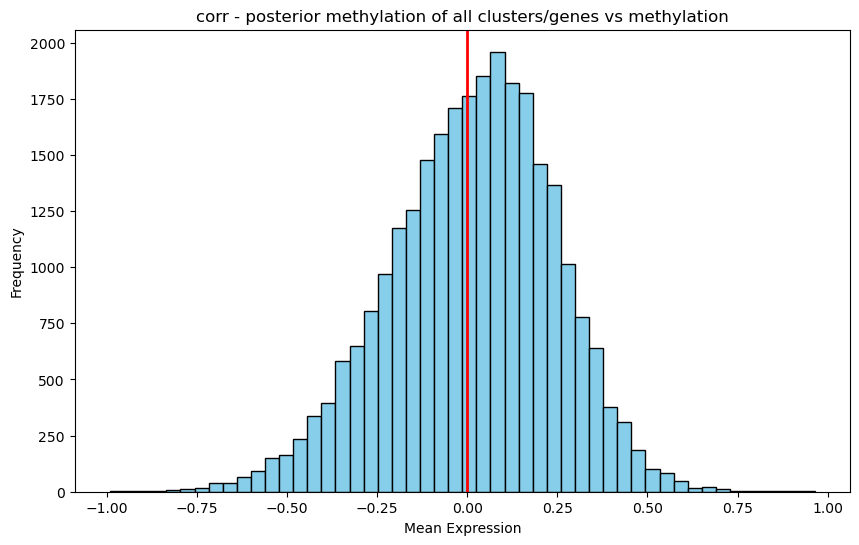

In [126]:
plt.figure(figsize=(10, 6))
plt.hist(corr_post, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('corr - posterior methylation of all clusters/genes vs methylation')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [142]:
corr_post_filtered = mc_frac_post_filtered.corrwith(rna_cluster).dropna()

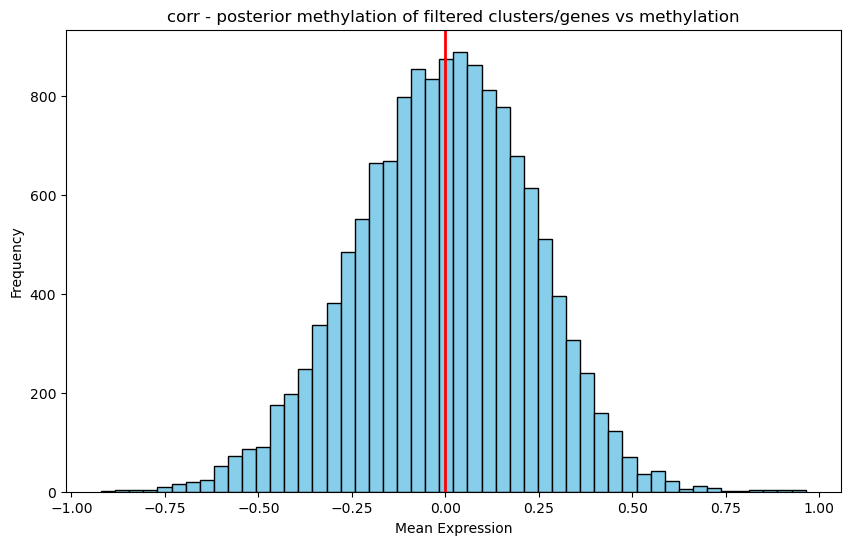

In [143]:
plt.figure(figsize=(10, 6))
plt.hist(corr_post_filtered, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('corr - posterior methylation of filtered clusters/genes vs methylation')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

# inspect posterior methylation trend

In [130]:
ww_mc_frac_post_filtered

gene,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01230,AT1G01240,AT1G01260,AT1G01320,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.403031,0.541702,-0.243113,-0.024634,-0.066832,0.199721,-0.195398,-0.229775,0.078941,0.343768,...,0.058929,-0.052187,-0.021441,-0.033407,0.158576,0.141983,0.134406,-0.133438,-0.007973,-0.041495
1,-0.409789,0.544236,-0.249373,-0.041023,-0.075291,0.175720,-0.199536,-0.233856,0.095357,0.337875,...,0.042980,-0.051093,-0.019646,-0.035287,0.147193,0.146303,0.112307,-0.100823,-0.017506,-0.047143
2,-0.453612,0.569300,-0.211182,-0.025273,-0.034506,0.201401,-0.202037,-0.274339,0.108223,0.348311,...,0.042337,-0.060531,-0.025295,-0.011931,0.208100,0.174282,0.111208,-0.121969,-0.026624,-0.045986
3,-0.377730,0.559477,-0.238186,-0.015916,-0.094377,0.197872,-0.212970,-0.221973,0.107881,0.339846,...,-0.059076,-0.055116,-0.019892,-0.028060,0.182227,0.102165,0.115328,-0.120117,-0.034174,-0.039744
4,-0.357944,0.518151,-0.190007,0.008125,-0.042736,0.213005,-0.134494,-0.242074,0.063541,0.338349,...,0.084079,-0.025867,-0.038036,-0.032550,0.169624,0.151664,0.113840,-0.140334,-0.033342,-0.082528
5,-0.350429,0.557197,-0.222229,0.026960,-0.106588,0.194612,-0.182555,-0.298387,0.077030,0.345840,...,0.001013,-0.065319,-0.030088,0.001349,0.182055,0.078265,0.128640,-0.116523,-0.008997,-0.038339
6,-0.363678,0.548478,-0.234779,-0.002735,-0.064314,0.193680,-0.170910,-0.230820,0.088354,0.359794,...,0.018673,-0.047004,-0.021356,-0.069892,0.140536,0.160686,0.076121,-0.162733,-0.015988,-0.069297
7,-0.286401,0.596069,-0.166587,0.013009,-0.080836,0.173099,-0.158988,-0.194983,0.071011,0.346887,...,0.091272,-0.059449,-0.028224,-0.079639,0.198876,0.128174,0.118570,-0.142024,-0.037275,-0.048242
8,-0.446639,0.551384,-0.331306,-0.052466,-0.106549,0.221422,-0.126214,-0.221677,0.086600,0.373335,...,0.018100,-0.057166,0.000852,-0.010870,0.216132,0.083811,0.125213,-0.200841,-0.027742,-0.070817


In [138]:
ww_post_corr = ww_mc_frac_post_filtered.corrwith(ww_rna_cluster).dropna()

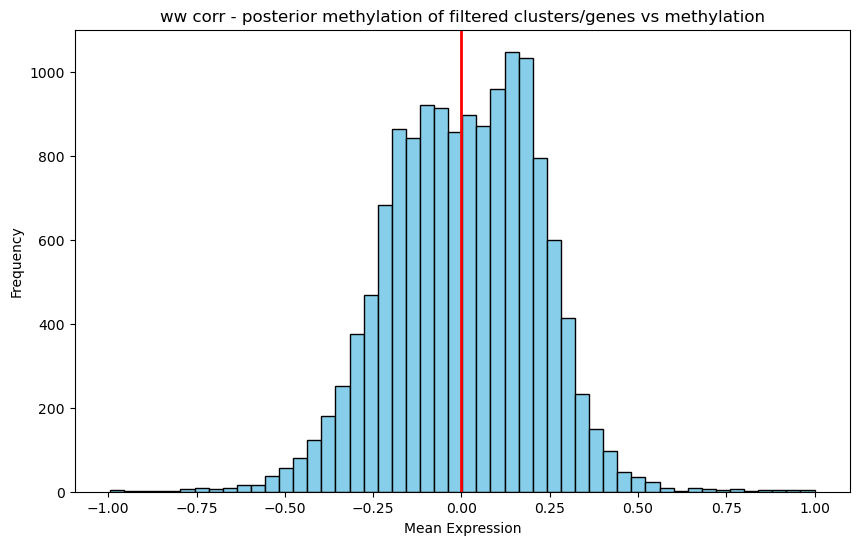

In [139]:
plt.figure(figsize=(10, 6))
plt.hist(ww_post_corr, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('ww corr - posterior methylation of filtered clusters/genes vs methylation')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [140]:
sd_post_corr = ww_mc_frac_post_filtered.corrwith(sd_rna_cluster).dropna()

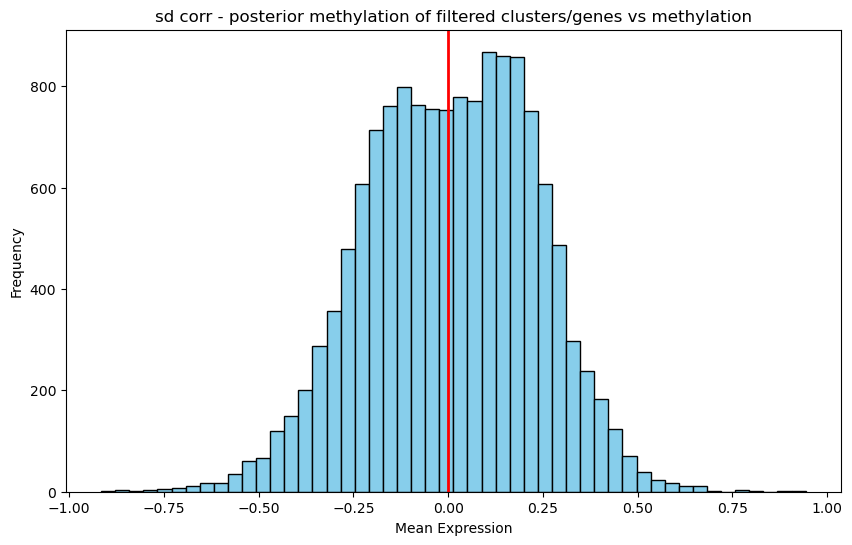

In [144]:
plt.figure(figsize=(10, 6))
plt.hist(sd_post_corr, bins=50, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('sd corr - posterior methylation of filtered clusters/genes vs methylation')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

# inspect raw methylation trend

In [158]:
ww_mc_frac_filtered

gene,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01230,AT1G01240,AT1G01260,AT1G01320,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.068376,0.596395,0.136644,0.116766,0.130631,0.296293,0.065158,0.055556,0.209016,0.390273,...,0.200622,0.040860,0.038214,0.121091,0.293188,0.284182,0.237477,0.092537,0.145345,0.079075
1,0.060131,0.601385,0.121901,0.092634,0.109624,0.283717,0.062295,0.040902,0.214988,0.381997,...,0.182347,0.038113,0.037849,0.123645,0.277135,0.286299,0.214347,0.102347,0.140687,0.071488
2,0.070845,0.625183,0.147388,0.113439,0.160406,0.301356,0.081001,0.037277,0.231660,0.391481,...,0.201326,0.048077,0.031186,0.141148,0.343199,0.323966,0.214171,0.078125,0.143872,0.085793
3,0.058161,0.616685,0.127559,0.128301,0.120092,0.305375,0.067674,0.059358,0.245838,0.388165,...,0.075188,0.047126,0.039979,0.119555,0.312711,0.256658,0.228023,0.109082,0.116558,0.068627
4,0.079710,0.576723,0.157390,0.138829,0.137725,0.323350,0.109017,0.048077,0.201373,0.384458,...,0.209286,0.066191,0.026959,0.146825,0.285898,0.291120,0.239721,0.116312,0.114379,0.068447
5,0.077477,0.615215,0.145736,0.152381,0.133739,0.300537,0.084364,0.058647,0.227880,0.396014,...,0.125789,0.035169,0.029309,0.167484,0.318891,0.230276,0.240662,0.106004,0.132379,0.091307
6,0.066860,0.602498,0.109302,0.106904,0.138927,0.281139,0.092692,0.044693,0.225000,0.403055,...,0.136800,0.033991,0.038493,0.094655,0.304444,0.303883,0.207665,0.073482,0.134420,0.071429
7,0.084184,0.649500,0.114120,0.137931,0.102273,0.271613,0.069182,0.044554,0.196197,0.388128,...,0.282322,0.051067,0.041168,0.095296,0.348501,0.289210,0.240134,0.112084,0.112953,0.081323
8,0.067265,0.612366,0.102273,0.096732,0.095575,0.319793,0.065436,0.062035,0.213097,0.420506,...,0.147560,0.038591,0.051305,0.125598,0.366887,0.282723,0.248112,0.108108,0.103567,0.073140


In [164]:
def shuffle_dataframe_columns(df):
    """
    Shuffles the values among columns in the DataFrame.

    Parameters:
    - df: pd.DataFrame
        DataFrame with columns to shuffle.

    Returns:
    - pd.DataFrame
        DataFrame with shuffled column values.
    """
    # Create a copy to shuffle columns
    shuffled_df = df.copy()

    # Shuffle column names
    shuffled_columns = np.random.permutation(df.columns)

    # Assign values of shuffled columns to original columns
    for original, shuffled in zip(df.columns, shuffled_columns):
        shuffled_df[original] = df[shuffled].values
    
    return shuffled_df

# Shuffle the DataFrame columns
# shuffled_df = shuffle_dataframe_columns(ww_mc_frac_filtered)
# print(shuffled_df)
ww_rna_shuffled = shuffle_dataframe_columns(ww_rna_cluster)

In [156]:
ww_corr_shuffled = shuffled_df.corrwith(ww_rna_shuffled).dropna()
ww_corr_shuffled

AT1G01020    0.321439
AT1G01040    0.195909
AT1G01050   -0.155383
AT1G01060    0.009105
AT1G01150   -0.019374
               ...   
AT5G67540   -0.381633
AT5G67570    0.100832
AT5G67580   -0.194043
AT5G67610   -0.297534
AT5G67630    0.043062
Length: 13759, dtype: float64

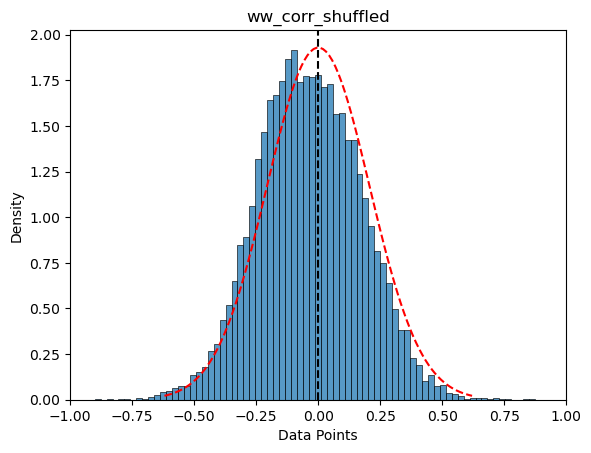

In [169]:
from scipy import stats
from scipy.stats import norm
# Assuming 'corr' is your data series
# Fixed mean at 0
data_mean = 0

# Use the standard deviation of your data for a better fit:
data_std = ww_corr_shuffled.std()

# Generate a normal distribution curve centered at zero
x = np.linspace(-3 * data_std, 3 * data_std, 100)  # Typically, +/- 3 standard deviations
y = norm.pdf(x, data_mean, data_std)  # Probability density function

# Plot the histogram of your data
sns.histplot(ww_corr_shuffled, kde=False, stat="density")  # 'stat="density"' normalizes the histogram

# Overlay the standard normal distribution curve
plt.plot(x, y, 'r--')  # 'r--' means red dashed line

# Draw a vertical line through zero on the x-axis
plt.axvline(x=0, color='k', linestyle='--')  # 'k' is color black, '--' dashed line

# Set x-axis limits
plt.xlim(-1, 1)

# Optional: Titles and labels
plt.title('ww_corr_shuffled')
plt.xlabel('Data Points')
plt.ylabel('Density')

plt.savefig('Histogram with Centered Normal Distribution Fit Marker Genes < 0.0001.png')
plt.show()
plt.close()

In [166]:
ww_corr = ww_mc_frac_filtered.corrwith(ww_rna_cluster).dropna()

In [167]:
ww_corr

AT1G01020    0.085870
AT1G01040   -0.009498
AT1G01050    0.214145
AT1G01060   -0.213530
AT1G01150   -0.191817
               ...   
AT5G67540    0.057778
AT5G67570   -0.093682
AT5G67580    0.073415
AT5G67610    0.000430
AT5G67630   -0.193815
Length: 13948, dtype: float64

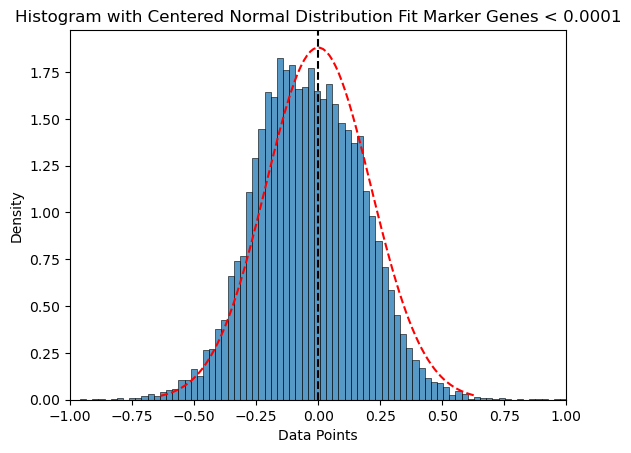

In [168]:
from scipy import stats
from scipy.stats import norm
# Assuming 'corr' is your data series
# Fixed mean at 0
data_mean = 0

# Use the standard deviation of your data for a better fit:
data_std = ww_corr.std()

# Generate a normal distribution curve centered at zero
x = np.linspace(-3 * data_std, 3 * data_std, 100)  # Typically, +/- 3 standard deviations
y = norm.pdf(x, data_mean, data_std)  # Probability density function

# Plot the histogram of your data
sns.histplot(ww_corr, kde=False, stat="density")  # 'stat="density"' normalizes the histogram

# Overlay the standard normal distribution curve
plt.plot(x, y, 'r--')  # 'r--' means red dashed line

# Draw a vertical line through zero on the x-axis
plt.axvline(x=0, color='k', linestyle='--')  # 'k' is color black, '--' dashed line

# Set x-axis limits
plt.xlim(-1, 1)

# Optional: Titles and labels
plt.title('Histogram with Centered Normal Distribution Fit Marker Genes < 0.0001')
plt.xlabel('Data Points')
plt.ylabel('Density')

plt.savefig('Histogram with Centered Normal Distribution Fit Marker Genes < 0.0001.png')
plt.show()
plt.close()

In [154]:
ww_mc_frac_filtered

gene,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01230,AT1G01240,AT1G01260,AT1G01320,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.068376,0.596395,0.136644,0.116766,0.130631,0.296293,0.065158,0.055556,0.209016,0.390273,...,0.200622,0.040860,0.038214,0.121091,0.293188,0.284182,0.237477,0.092537,0.145345,0.079075
1,0.060131,0.601385,0.121901,0.092634,0.109624,0.283717,0.062295,0.040902,0.214988,0.381997,...,0.182347,0.038113,0.037849,0.123645,0.277135,0.286299,0.214347,0.102347,0.140687,0.071488
2,0.070845,0.625183,0.147388,0.113439,0.160406,0.301356,0.081001,0.037277,0.231660,0.391481,...,0.201326,0.048077,0.031186,0.141148,0.343199,0.323966,0.214171,0.078125,0.143872,0.085793
3,0.058161,0.616685,0.127559,0.128301,0.120092,0.305375,0.067674,0.059358,0.245838,0.388165,...,0.075188,0.047126,0.039979,0.119555,0.312711,0.256658,0.228023,0.109082,0.116558,0.068627
4,0.079710,0.576723,0.157390,0.138829,0.137725,0.323350,0.109017,0.048077,0.201373,0.384458,...,0.209286,0.066191,0.026959,0.146825,0.285898,0.291120,0.239721,0.116312,0.114379,0.068447
5,0.077477,0.615215,0.145736,0.152381,0.133739,0.300537,0.084364,0.058647,0.227880,0.396014,...,0.125789,0.035169,0.029309,0.167484,0.318891,0.230276,0.240662,0.106004,0.132379,0.091307
6,0.066860,0.602498,0.109302,0.106904,0.138927,0.281139,0.092692,0.044693,0.225000,0.403055,...,0.136800,0.033991,0.038493,0.094655,0.304444,0.303883,0.207665,0.073482,0.134420,0.071429
7,0.084184,0.649500,0.114120,0.137931,0.102273,0.271613,0.069182,0.044554,0.196197,0.388128,...,0.282322,0.051067,0.041168,0.095296,0.348501,0.289210,0.240134,0.112084,0.112953,0.081323
8,0.067265,0.612366,0.102273,0.096732,0.095575,0.319793,0.065436,0.062035,0.213097,0.420506,...,0.147560,0.038591,0.051305,0.125598,0.366887,0.282723,0.248112,0.108108,0.103567,0.073140


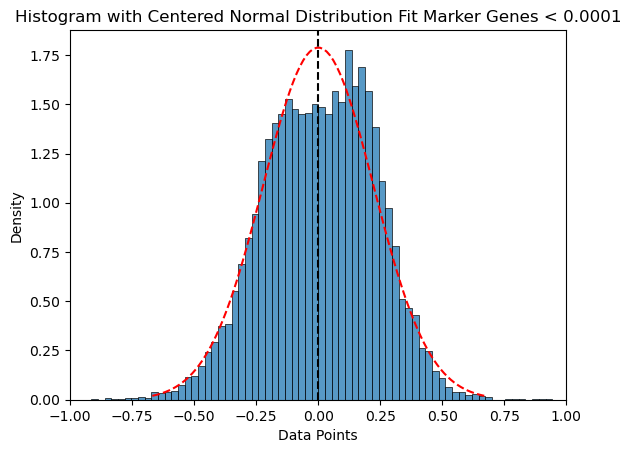

In [146]:

# Assuming 'corr' is your data series
# Fixed mean at 0
data_mean = 0

# Use the standard deviation of your data for a better fit:
data_std = sd_corr.std()

# Generate a normal distribution curve centered at zero
x = np.linspace(-3 * data_std, 3 * data_std, 100)  # Typically, +/- 3 standard deviations
y = norm.pdf(x, data_mean, data_std)  # Probability density function

# Plot the histogram of your data
sns.histplot(sd_corr, kde=False, stat="density")  # 'stat="density"' normalizes the histogram

# Overlay the standard normal distribution curve
plt.plot(x, y, 'r--')  # 'r--' means red dashed line

# Draw a vertical line through zero on the x-axis
plt.axvline(x=0, color='k', linestyle='--')  # 'k' is color black, '--' dashed line

# Set x-axis limits
plt.xlim(-1, 1)

# Optional: Titles and labels
plt.title('Histogram with Centered Normal Distribution Fit Marker Genes < 0.0001')
plt.xlabel('Data Points')
plt.ylabel('Density')

plt.savefig('Histogram with Centered Normal Distribution Fit Marker Genes < 0.0001.png')
plt.show()
plt.close()

In [56]:
# corr_diff = sd_corr - ww_corr
# corr_diff

In [55]:
# plt.figure(figsize=(10, 6))
# plt.hist(corr_diff, bins=50, color='skyblue', edgecolor='black')
# plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
# plt.title('corr diff')
# plt.xlabel('Mean Expression')
# plt.ylabel('Frequency')
# plt.show()

In [99]:
diff_raw_filtered = sd_filtered - ww_filtered
diff_raw_filtered

gene,AT1G01010,AT1G01020,AT1G01040,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01230,AT1G01240,AT1G01260,...,AT5G67385,AT5G67440,AT5G67470,AT5G67500,AT5G67530,AT5G67540,AT5G67570,AT5G67580,AT5G67610,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0,NaN,0.002972,0.004426,-0.009581,0.008514,-0.020192,-0.007854,0.003709,-0.006564,0.006397,...,0.023313,-0.002674,-0.007976,-0.013394,0.013397,0.025815,-0.036772,0.016171,0.004538,0.000363
1,NaN,-0.004651,0.002697,0.015523,0.038660,-0.007036,0.000973,-0.004204,0.003158,-0.022966,...,0.028355,-0.003450,-0.004306,-0.005500,-0.003055,0.021374,0.010853,-0.001669,0.021222,0.000117
2,NaN,-0.021143,-0.006636,-0.028927,0.012487,-0.042232,0.006201,0.013880,0.000344,-0.033937,...,0.027011,-0.005864,0.005636,-0.027774,-0.026361,-0.005877,0.011567,0.017169,0.009545,-0.010052
3,NaN,-0.025444,-0.004133,0.009150,0.000954,0.005587,-0.019926,-0.002337,0.016510,-0.047926,...,0.048053,0.001223,0.002749,0.007607,0.027629,0.019572,-0.009393,0.002329,0.024835,0.023424
4,NaN,-0.023152,0.039577,-0.039208,-0.005426,-0.005991,-0.007719,-0.026584,-0.001336,0.029347,...,0.027820,-0.018868,0.014183,-0.033420,0.025425,0.016353,-0.029012,-0.015858,0.009437,0.001406
5,NaN,-0.042079,-0.015305,-0.046367,-0.034767,0.016448,0.019763,-0.030141,-0.022150,-0.030877,...,-0.017611,0.000894,0.006607,-0.065093,-0.007309,0.087602,0.009783,-0.001218,0.012938,-0.015734
6,NaN,-0.011584,0.016281,0.042905,0.029587,0.002223,0.032985,-0.031548,-0.000724,0.007999,...,0.088896,0.007894,-0.014093,0.047244,0.035833,-0.062632,0.010066,0.011624,0.002180,0.005595
7,NaN,-0.047461,-0.002099,0.014616,-0.026820,0.004379,-0.035453,0.013349,-0.001762,0.003638,...,0.035353,-0.011863,0.015965,0.021793,-0.005984,0.026415,-0.015323,0.040002,0.030742,-0.013141
8,NaN,-0.005915,0.035268,0.086768,0.035850,0.029251,-0.011091,0.022799,-0.008701,0.060906,...,0.049725,-0.008774,-0.027531,-0.010722,-0.075056,0.001619,-0.038615,-0.027879,0.063853,0.019097


In [90]:
corr_diff = diff_raw_filtered.corrwith(rna_diff_cluster).dropna()

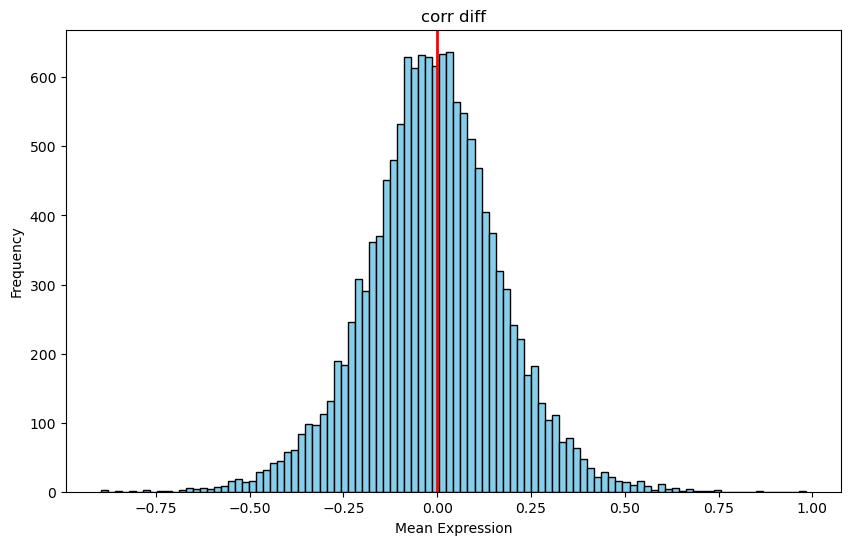

In [92]:
plt.figure(figsize=(10, 6))
plt.hist(corr_diff, bins=100, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('corr diff')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [87]:
diff_raw_filtered_mean = diff_raw_filtered.mean(axis = 0)
diff_raw_filtered_mean[diff_raw_filtered_mean > 0] # 0.01 - 6169
diff_raw_filtered_mean[diff_raw_filtered_mean < -0.1] #-0.01 - 2579

gene
AT1G05035   -0.122433
AT1G54420   -0.100395
AT1G59835   -0.154599
AT1G67635   -0.114585
AT2G01010   -0.107391
AT2G04005   -0.115834
AT2G07725   -0.126141
AT2G07835   -0.115555
AT2G08885   -0.134578
AT2G09400   -0.100195
AT3G03865   -0.103342
AT3G04405   -0.112986
AT3G05085   -0.112373
AT3G06395   -0.141398
AT3G08825   -0.141263
AT3G08935   -0.126870
AT3G44440   -0.108585
AT3G45820   -0.110985
AT3G60950   -0.236667
AT4G04225   -0.136750
AT4G36925   -0.156855
AT5G03405   -0.115933
AT5G03425   -0.134533
AT5G05335   -0.130748
AT5G08055   -0.135273
AT5G08315   -0.123640
AT5G08800   -0.333333
AT5G21125   -0.104285
AT5G53450   -0.119179
dtype: float64

In [97]:
diff_raw_negative = diff_raw_filtered_mean[diff_raw_filtered_mean<-0]
diff_raw_negative

gene
AT1G01020   -0.018280
AT1G01230   -0.013258
AT1G01240   -0.006597
AT1G01260   -0.000868
AT1G01320   -0.017574
               ...   
AT5G67130   -0.003597
AT5G67470   -0.012343
AT5G67500   -0.011334
AT5G67570   -0.039154
AT5G67630   -0.010043
Length: 5082, dtype: float64

In [98]:
diff_raw_positive = diff_raw_filtered_mean[diff_raw_filtered_mean>0]
diff_raw_positive

gene
AT1G01040    0.005272
AT1G01050    0.030624
AT1G01060    0.004448
AT1G01150    0.004093
AT1G01220    0.003263
               ...   
AT5G67440    0.000864
AT5G67530    0.014722
AT5G67540    0.011054
AT5G67580    0.017795
AT5G67610    0.020400
Length: 9193, dtype: float64

In [102]:
diff_mc_negative = diff_raw_filtered[diff_raw_negative.index]
diff_mc_negative

gene,AT1G01020,AT1G01230,AT1G01240,AT1G01260,AT1G01320,AT1G01340,AT1G01440,AT1G01530,AT1G01540,AT1G01670,...,AT5G66620,AT5G66810,AT5G66880,AT5G66920,AT5G67090,AT5G67130,AT5G67470,AT5G67500,AT5G67570,AT5G67630
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.002972,0.003709,-0.006564,0.006397,-0.009822,-0.026592,-0.013758,-0.030532,0.015984,0.012611,...,-0.007702,-0.003906,0.014619,-0.007681,0.006315,-0.009174,-0.007976,-0.013394,-0.036772,0.000363
1,-0.004651,-0.004204,0.003158,-0.022966,0.005499,-0.015638,-0.018250,-0.005627,-0.011245,0.000050,...,-0.011960,0.014625,-0.011322,-0.003502,0.012147,0.001223,-0.004306,-0.005500,0.010853,0.000117
2,-0.021143,0.013880,0.000344,-0.033937,-0.000862,0.002018,-0.025280,0.069325,0.011226,0.001163,...,-0.030046,-0.014124,-0.006216,-0.019566,0.018123,-0.005059,0.005636,-0.027774,0.011567,-0.010052
3,-0.025444,-0.002337,0.016510,-0.047926,0.026919,0.017930,0.012927,-0.031158,0.015928,0.000380,...,0.006041,-0.007522,0.004049,-0.006571,-0.002042,-0.003384,0.002749,0.007607,-0.009393,0.023424
4,-0.023152,-0.026584,-0.001336,0.029347,0.012748,-0.041056,-0.002633,-0.080599,0.001530,0.035884,...,-0.013033,-0.005683,-0.001332,-0.012275,0.009750,0.014781,0.014183,-0.033420,-0.029012,0.001406
5,-0.042079,-0.030141,-0.022150,-0.030877,0.009531,0.028236,0.029563,-0.005770,-0.006667,-0.042266,...,0.004175,-0.021061,-0.022370,0.000842,0.008063,-0.012636,0.006607,-0.065093,0.009783,-0.015734
6,-0.011584,-0.031548,-0.000724,0.007999,-0.007443,0.023220,-0.052829,-0.183435,0.030242,-0.000057,...,0.007134,0.011953,-0.005300,0.002476,0.019227,-0.001831,-0.014093,0.047244,0.010066,0.005595
7,-0.047461,0.013349,-0.001762,0.003638,0.025240,-0.023562,0.001085,0.070085,0.012763,-0.067195,...,-0.021850,-0.040524,-0.001723,-0.012573,-0.009372,0.000290,0.015965,0.021793,-0.015323,-0.013141
8,-0.005915,0.022799,-0.008701,0.060906,-0.052564,-0.010253,-0.045816,-0.164707,-0.014138,-0.011562,...,0.009262,-0.054514,-0.039607,0.017433,-0.005719,-0.002094,-0.027531,-0.010722,-0.038615,0.019097


In [104]:
diff_mc_positive =  diff_raw_filtered[diff_raw_positive.index]
diff_mc_positive

gene,AT1G01040,AT1G01050,AT1G01060,AT1G01150,AT1G01220,AT1G01350,AT1G01450,AT1G01510,AT1G01550,AT1G01650,...,AT5G67240,AT5G67250,AT5G67320,AT5G67340,AT5G67385,AT5G67440,AT5G67530,AT5G67540,AT5G67580,AT5G67610
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.004426,-0.009581,0.008514,-0.020192,-0.007854,0.000695,0.038921,0.014026,0.005120,0.047174,...,0.000924,0.000069,0.005009,0.048430,0.023313,-0.002674,0.013397,0.025815,0.016171,0.004538
1,0.002697,0.015523,0.038660,-0.007036,0.000973,-0.008603,0.012561,0.008656,0.000425,0.009496,...,0.011805,0.009773,0.022740,0.004467,0.028355,-0.003450,-0.003055,0.021374,-0.001669,0.021222
2,-0.006636,-0.028927,0.012487,-0.042232,0.006201,-0.009572,0.062948,-0.005387,-0.006353,0.093307,...,-0.036218,-0.000833,-0.003951,0.069570,0.027011,-0.005864,-0.026361,-0.005877,0.017169,0.009545
3,-0.004133,0.009150,0.000954,0.005587,-0.019926,-0.009967,0.030890,0.005155,0.001641,0.015633,...,0.002571,0.022579,-0.005994,0.038410,0.048053,0.001223,0.027629,0.019572,0.002329,0.024835
4,0.039577,-0.039208,-0.005426,-0.005991,-0.007719,-0.034433,-0.040758,0.002602,0.008167,0.002364,...,0.004766,-0.004079,0.038020,0.027120,0.027820,-0.018868,0.025425,0.016353,-0.015858,0.009437
5,-0.015305,-0.046367,-0.034767,0.016448,0.019763,0.022243,-0.017760,0.013824,-0.019036,0.028884,...,0.002180,-0.018537,0.040181,0.002659,-0.017611,0.000894,-0.007309,0.087602,-0.001218,0.012938
6,0.016281,0.042905,0.029587,0.002223,0.032985,0.037494,-0.016386,0.000357,0.002759,0.011913,...,0.010757,0.005115,0.031872,-0.017531,0.088896,0.007894,0.035833,-0.062632,0.011624,0.002180
7,-0.002099,0.014616,-0.026820,0.004379,-0.035453,-0.122894,-0.066795,0.020870,0.024354,-0.016965,...,0.009162,0.002553,-0.018311,-0.028906,0.035353,-0.011863,-0.005984,0.026415,0.040002,0.030742
8,0.035268,0.086768,0.035850,0.029251,-0.011091,-0.031934,0.052900,0.011345,-0.005779,-0.003478,...,0.039082,-0.001719,-0.001571,0.002671,0.049725,-0.008774,-0.075056,0.001619,-0.027879,0.063853


In [108]:
neg = diff_mc_negative.corrwith(diff_rna_cluster)

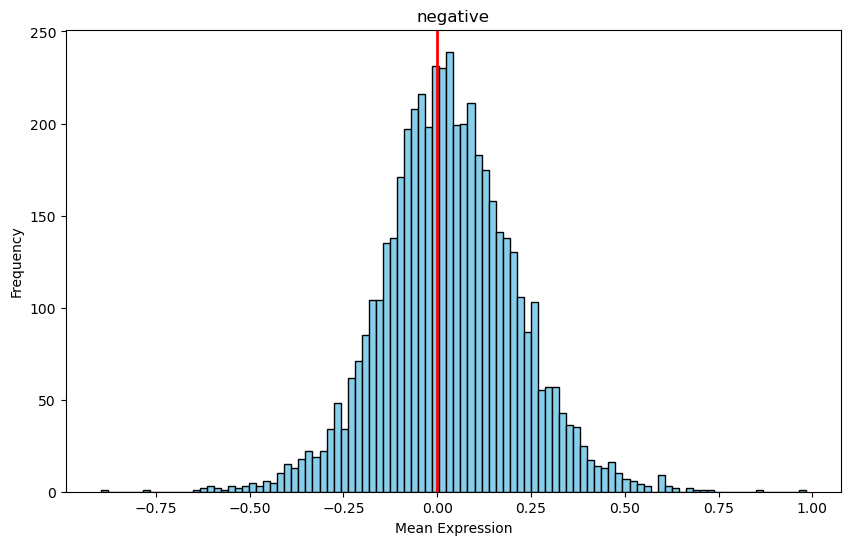

In [109]:
plt.figure(figsize=(10, 6))
plt.hist(neg, bins=100, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('negative')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [110]:
pos = diff_mc_positive.corrwith(diff_rna_cluster)

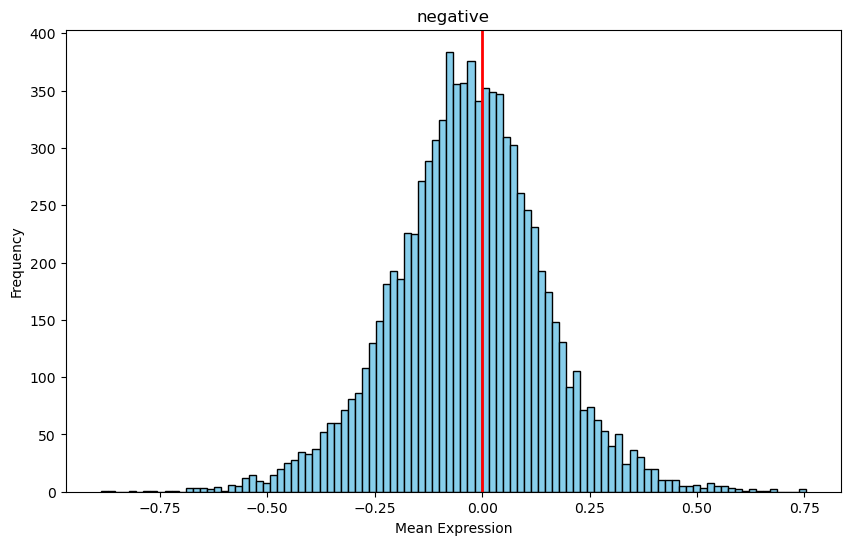

In [111]:
plt.figure(figsize=(10, 6))
plt.hist(pos, bins=100, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('negative')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [18]:
diff_raw_filtered_mean['AT5G53450']

-0.11917948143123229

In [19]:
diff_post = sd_post-ww_post

In [20]:
diff_raw = sd_raw - ww_raw
diff_raw_mean = diff_raw.mean(axis = 0)
diff_raw_mean[diff_raw_mean<-0.01] #0_13000, -0.01_2919
# diff_raw_mean[diff_raw_mean>0.01] #0_19000 #0.01_6594

gene
AT1G01020   -0.018280
AT1G01230   -0.013258
AT1G01250   -0.010530
AT1G01320   -0.017574
AT1G01440   -0.015424
               ...   
AT5G67230   -0.012924
AT5G67470   -0.012343
AT5G67500   -0.011334
AT5G67570   -0.039154
AT5G67630   -0.010043
Length: 2919, dtype: float64

NameError: name 'diff_raw_mean' is not defined

In [21]:
diff_post_mean = diff_post.mean(axis=0)


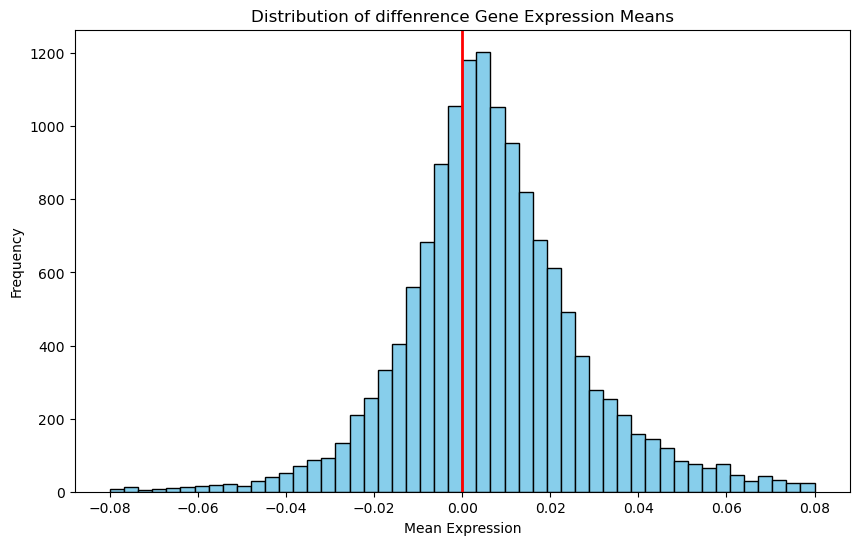

In [22]:
# Plotting the distribution of means
plt.figure(figsize=(10, 6))
plt.hist(diff_raw_filtered_mean, bins=50, color='skyblue', edgecolor='black', range=(-0.08, 0.08))
plt.axvline(0, color='red', linewidth=2, label='x=0 axis')
plt.title('Distribution of diffenrence Gene Expression Means')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [23]:
diff_raw['AT5G53450']

cluster
0    -0.127718
1    -0.053118
2    -0.166581
3    -0.118253
4    -0.127129
5    -0.190256
6    -0.140134
7    -0.030373
8    -0.165375
9    -0.095000
10   -0.086207
11   -0.066688
12   -0.260837
13   -0.044317
14   -0.115707
Name: AT5G53450, dtype: float64

In [24]:
diff_raw['AT4G04610']

cluster
0     0.031901
1     0.031316
2     0.038943
3     0.037530
4     0.001842
5    -0.012081
6     0.063691
7    -0.100483
8    -0.026788
9    -0.069431
10    0.057591
11    0.009508
12    0.025726
13   -0.106803
14   -0.001609
Name: AT4G04610, dtype: float64

In [25]:
diff_raw['AT2G33380']

cluster
0    -0.083701
1    -0.054457
2    -0.056192
3    -0.049362
4    -0.030133
5    -0.036468
6    -0.015595
7    -0.049162
8    -0.047619
9    -0.166667
10    0.015930
11   -0.088672
12    0.019599
13   -0.040451
14    0.153898
Name: AT2G33380, dtype: float64

In [26]:
diff_raw['AT1G57590']

cluster
0    -0.080544
1    -0.047977
2    -0.018603
3    -0.012758
4    -0.018094
5     0.006296
6     0.028263
7    -0.058832
8     0.021237
9    -0.030166
10   -0.043215
11   -0.088850
12   -0.049365
13    0.065211
14    0.016156
Name: AT1G57590, dtype: float64

In [ ]:
ww_mean = ww_post.mean(axis = 0)
ww_mean

In [ ]:
sd_mean = sd_post.mean(axis=0)

In [ ]:
diff_mean = sd_mean-ww_mean
diff_mean

In [ ]:
# Plotting the distribution of means
plt.figure(figsize=(10, 6))
plt.hist(diff_mean, bins=50, color='skyblue', edgecolor='black', range=(-0.08, 0.08))
plt.title('Distribution of diffenrence Gene Expression Means')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Plotting the distribution of means
plt.figure(figsize=(10, 6))
plt.hist(ww_mean, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Gene Expression Means')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Plotting the distribution of means
plt.figure(figsize=(10, 6))
plt.hist(sd_mean, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Gene Expression Means')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [ ]:
diff_mean = sd_mean-ww_mean
diff_mean

In [ ]:
# Plotting the distribution of means
plt.figure(figsize=(10, 6))
plt.hist(diff_mean, bins=50, color='skyblue', edgecolor='black', range=(-0.08, 0.08))
plt.title('Distribution of diffenrence Gene Expression Means')
plt.xlabel('Mean Expression')
plt.ylabel('Frequency')
plt.show()

In [163]:
import pandas as pd
import numpy as np

# Sample DataFrame setup
df = pd.DataFrame({
    'A': [1, 2, 3],
    'B': [4, 5, 6],
    'C': [7, 8, 9]
})

def shuffle_dataframe_columns(df):
    """
    Shuffles the values among columns in the DataFrame.

    Parameters:
    - df: pd.DataFrame
        DataFrame with columns to shuffle.

    Returns:
    - pd.DataFrame
        DataFrame with shuffled column values.
    """
    # Create a copy to shuffle columns
    shuffled_df = df.copy()

    # Shuffle column names
    shuffled_columns = np.random.permutation(df.columns)

    # Assign values of shuffled columns to original columns
    for original, shuffled in zip(df.columns, shuffled_columns):
        shuffled_df[original] = df[shuffled].values
    
    return shuffled_df

# Shuffle the DataFrame columns
shuffled_df = shuffle_dataframe_columns(df)
print(shuffled_df)


   A  B  C
0  4  7  1
1  5  8  2
2  6  9  3
